# Basic Grid Simulation and Plotting

This notebook demonstrates the basic functionality of WEC-GRID:
- Loading a power system model
- Running a basic simulation
- Creating visualizations with the plotting module
- Exploring grid state data

This example uses the IEEE 14-bus test system for demonstration.

In [8]:
%%capture
'''
if this is your first time running WEC-GRID, you will need to set the database path to the location of your WECGrid.db file. Uncomment the line below and provide the correct path to your database file.
'''
# import wecgrid
# setup = wecgrid.Engine() 
# setup.database.set_database_path('./WECGrid.db')

## Initialize the WEC-GRID and an Engine

The Engine is the core component that manages power system simulations. We'll initialize it with the IEEE 14-bus test system.

In [9]:
import wecgrid

In [10]:
example1 = wecgrid.Engine()
example1.case("grid_models/IEEE_14_bus.RAW")
example1.load(["pypsa"])

--- 

## Explore the Grid State

WEC-Grid uses a unified GridState object to represent power system data across different power system modelers. Let's examine the grid structure.

In [11]:
grid = example1.pypsa.grid
grid

GridState:
├─ Components:
│   ├─ bus:   14 components
│   ├─ gen:   5 components
│   ├─ line:  17 components
│   └─ load:  11 components
├─ Case: IEEE 14 bus
└─ Modeler: pypsa

--- 

## Run a Basic Steady State Power Flow Simulation.

Now let's run a power flow simulation to solve the grid state and analyze the results with a load.

In [12]:
example1.simulate(num_steps=20) # only run a few iterations
example1.pypsa.report

PyPSA Simulating: 100%|██████████| 20/20 [00:02<00:00,  9.98step/s]


SolveReport: Successful, steps=20, time=2.01s, case=IEEE 14 bus, sw=pypsa

---

## Visualize the Grid with WEC-GRID Plotting

The WECGridPlot module provides basic visualization capabilities including single-line diagrams, time series plots, and more.

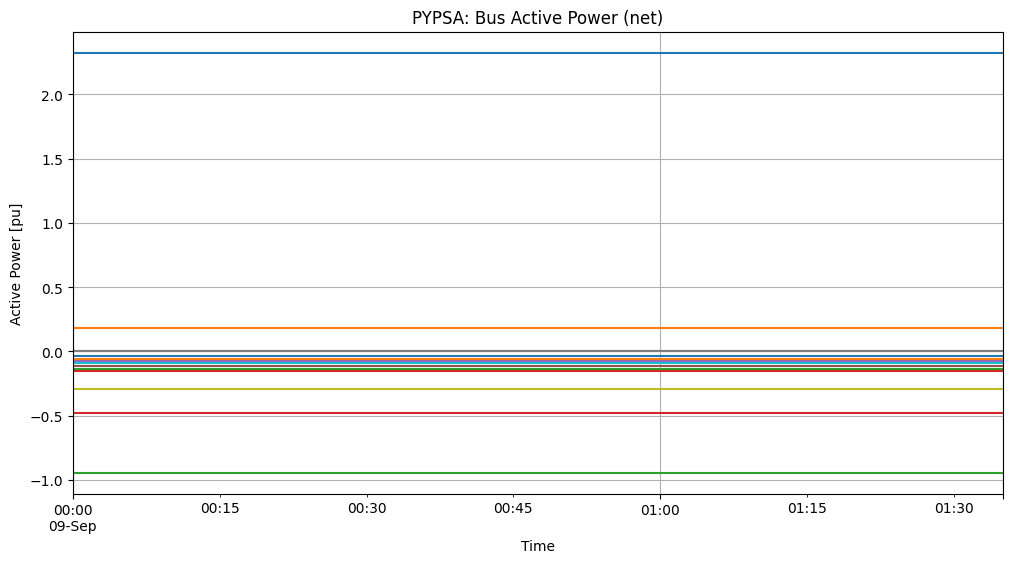

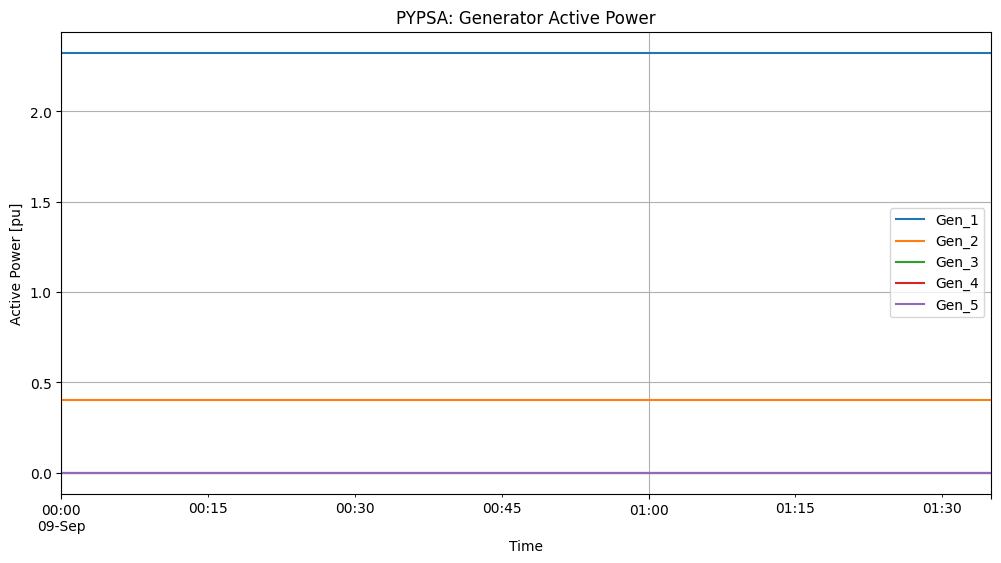

SLD Data Summary:
  Buses: 14
  Lines: 17
  Generators: 5
  Loads: 11


(<Figure size 1400x1000 with 1 Axes>,
 <AxesSubplot:title={'center':'Single-Line Diagram - IEEE 14 bus (PYPSA)'}>)

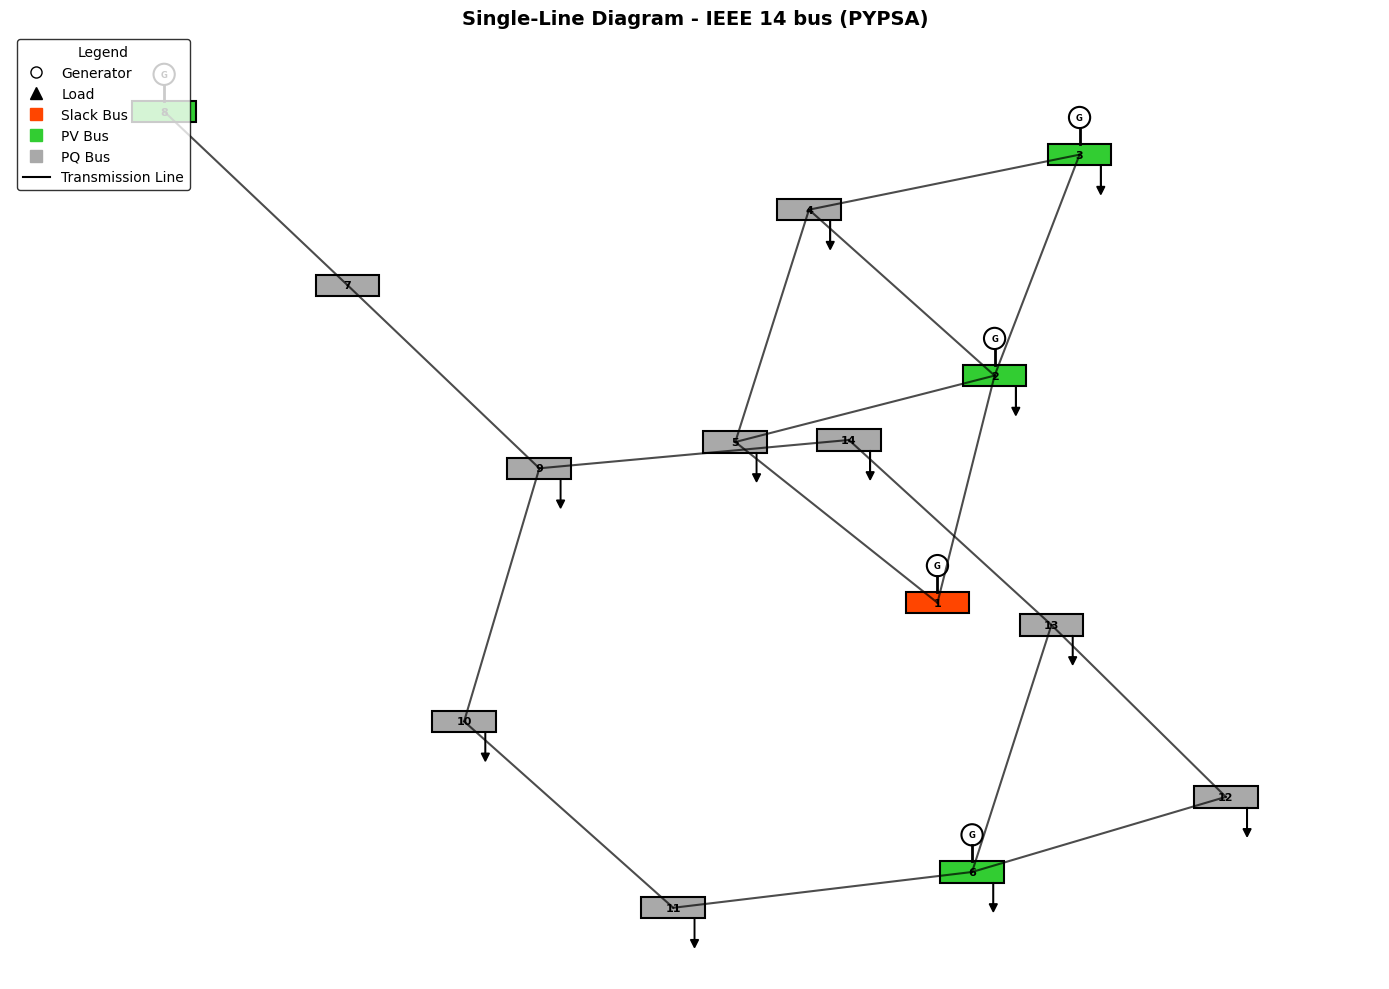

In [13]:
# should see flat lines
plot = example1.plot
plot.bus()
plot.gen()
plot.sld()